In [ ]:
import pandas as pd
import numpy as np

matches = pd.read_csv("matches_clean.csv")
ball_by_ball = pd.read_csv("ball_by_ball_clean.csv")
team_stats = pd.read_csv("team_stats.csv")
venue_stats = pd.read_csv("venue_stats.csv")

In [ ]:
team_matches = pd.concat([
    matches[["match_id", "team1"]]
        .rename(columns={"team1": "team"}),

    matches[["match_id", "team2"]]
        .rename(columns={"team2": "team"})
])

team_matches.head()

,match_id,team
0,M0001,Punjab Kings
1,M0002,Mumbai Indians
2,M0003,Chennai Super Kings
3,M0004,Chennai Super Kings
4,M0005,Rajasthan Royals


In [ ]:
matches_played = (
    team_matches.groupby("team")
    .size()
    .reset_index(name="matches_played")
)

matches_played.sort_values(
    "matches_played",
    ascending=False
)

,team,matches_played
13,Royal Challengers Bengaluru,283
8,Mumbai Indians,277
10,Punjab Kings,276
2,Delhi Capitals,264
6,Kolkata Knight Riders,253
0,Chennai Super Kings,239
11,Rajasthan Royals,228
14,Sunrisers Hyderabad,187
1,Deccan Chargers,69
7,Lucknow Super Giants,57


In [ ]:
matches_won = (
    matches.groupby("winner")
    .size()
    .reset_index(name="matches_won")
    .rename(columns={"winner": "team"})
)

matches_won.sort_values(
    "matches_won",
    ascending=False
)

,team,matches_won
13,Royal Challengers Bengaluru,144
10,Punjab Kings,143
8,Mumbai Indians,130
0,Chennai Super Kings,129
6,Kolkata Knight Riders,128
2,Delhi Capitals,122
11,Rajasthan Royals,99
14,Sunrisers Hyderabad,93
1,Deccan Chargers,31
9,Pune Warriors India,27


In [ ]:
franchise_stats = matches_played.merge(
    matches_won,
    on="team",
    how="left"
)

franchise_stats["matches_won"] = (
    franchise_stats["matches_won"]
    .fillna(0)
)

franchise_stats.head()

,team,matches_played,matches_won
0,Chennai Super Kings,239,129
1,Deccan Chargers,69,31
2,Delhi Capitals,264,122
3,Gujarat Lions,37,20
4,Gujarat Titans,49,19


In [ ]:
franchise_stats["win_percentage"] = round(
    (
        franchise_stats["matches_won"]
        /
        franchise_stats["matches_played"]
    ) * 100,
    2
)

franchise_stats.head()

,team,matches_played,matches_won,win_percentage
0,Chennai Super Kings,239,129,53.97
1,Deccan Chargers,69,31,44.93
2,Delhi Capitals,264,122,46.21
3,Gujarat Lions,37,20,54.05
4,Gujarat Titans,49,19,38.78


In [ ]:
franchise_stats["matches_lost"] = (
    franchise_stats["matches_played"]
    -
    franchise_stats["matches_won"]
)

franchise_stats.head()

,team,matches_played,matches_won,win_percentage,matches_lost
0,Chennai Super Kings,239,129,53.97,110
1,Deccan Chargers,69,31,44.93,38
2,Delhi Capitals,264,122,46.21,142
3,Gujarat Lions,37,20,54.05,17
4,Gujarat Titans,49,19,38.78,30


In [ ]:
toss_wins = (
    matches[matches["toss_winner"] == matches["winner"]]
    .groupby("winner")
    .size()
    .reset_index(name="wins_after_winning_toss")
    .rename(columns={"winner":"team"})
)

In [ ]:
franchise_stats = franchise_stats.merge(
    toss_wins,
    on="team",
    how="left"
)

franchise_stats["wins_after_winning_toss"] = (
    franchise_stats["wins_after_winning_toss"]
    .fillna(0)
)

In [ ]:
franchise_stats["toss_dependency_pct"] = round(
    (
        franchise_stats["wins_after_winning_toss"]
        /
        franchise_stats["matches_won"]
    ) * 100,
    2
)

franchise_stats.head()

,team,matches_played,matches_won,win_percentage,matches_lost,wins_after_winning_toss,toss_dependency_pct
0,Chennai Super Kings,239,129,53.97,110,62,48.06
1,Deccan Chargers,69,31,44.93,38,13,41.94
2,Delhi Capitals,264,122,46.21,142,64,52.46
3,Gujarat Lions,37,20,54.05,17,1,5.00
4,Gujarat Titans,49,19,38.78,30,8,42.11


In [ ]:
home_venues = {
    "Chennai Super Kings":"MA Chidambaram Stadium",
    "Mumbai Indians":"Wankhede Stadium",
    "Royal Challengers Bengaluru":"M Chinnaswamy Stadium",
    "Kolkata Knight Riders":"Eden Gardens",
    "Rajasthan Royals":"Sawai Mansingh Stadium",
    "Delhi Capitals":"Arun Jaitley Stadium",
    "Punjab Kings":"Punjab Cricket Association Stadium",
    "Sunrisers Hyderabad":"Rajiv Gandhi International Stadium",
    "Lucknow Super Giants":"BRSABV Ekana Stadium",
    "Gujarat Titans":"Narendra Modi Stadium"
}

In [ ]:
home_wins = []

for team, venue in home_venues.items():

    wins = matches[
        (matches["winner"] == team)
        &
        (matches["venue"] == venue)
    ].shape[0]

    home_wins.append([team, wins])

home_wins = pd.DataFrame(
    home_wins,
    columns=["team", "home_wins"]
)

home_wins.head()

,team,home_wins
0,Chennai Super Kings,0
1,Mumbai Indians,41
2,Royal Challengers Bengaluru,0
3,Kolkata Knight Riders,38
4,Rajasthan Royals,34


In [ ]:
franchise_stats = franchise_stats.merge(
    home_wins,
    on="team",
    how="left"
)

franchise_stats["home_wins"] = (
    franchise_stats["home_wins"]
    .fillna(0)
)

In [ ]:
franchise_stats["away_wins"] = (
    franchise_stats["matches_won"]
    -
    franchise_stats["home_wins"]
)

In [ ]:
franchise_stats["strength_score"] = round(
    (
        franchise_stats["win_percentage"] * 0.6
        +
        (100 - franchise_stats["toss_dependency_pct"]) * 0.4
    ),
    2
)

In [ ]:
franchise_rankings = franchise_stats.sort_values(
    "strength_score",
    ascending=False
)

franchise_rankings.reset_index(
    drop=True,
    inplace=True
)

franchise_rankings.head(10)

,team,matches_played,matches_won,win_percentage,matches_lost,wins_after_winning_toss,toss_dependency_pct,home_wins,away_wins,strength_score
0,Gujarat Lions,37,20,54.05,17,1,5.00,0.0,20.0,70.43
1,Rising Pune Supergiant,35,19,54.29,16,8,42.11,0.0,19.0,55.73
2,Pune Warriors India,47,27,57.45,20,14,51.85,0.0,27.0,53.73
3,Punjab Kings,276,143,51.81,133,63,44.06,54.0,89.0,53.46
4,Chennai Super Kings,239,129,53.97,110,62,48.06,0.0,129.0,53.16
5,Kolkata Knight Riders,253,128,50.59,125,63,49.22,38.0,90.0,50.67
6,Kochi Tuskers Kerala,15,6,40.00,9,2,33.33,0.0,6.0,50.67
7,Mumbai Indians,277,130,46.93,147,57,43.85,41.0,89.0,50.62
8,Deccan Chargers,69,31,44.93,38,13,41.94,0.0,31.0,50.18
9,Sunrisers Hyderabad,187,93,49.73,94,46,49.46,0.0,93.0,50.05


In [ ]:
franchise_rankings = franchise_rankings[
    [
        "team",
        "matches_played",
        "matches_won",
        "matches_lost",
        "win_percentage",
        "home_wins",
        "away_wins",
        "toss_dependency_pct",
        "strength_score"
    ]
]

franchise_rankings.head(10)

,team,matches_played,matches_won,matches_lost,win_percentage,home_wins,away_wins,toss_dependency_pct,strength_score
0,Gujarat Lions,37,20,17,54.05,0.0,20.0,5.00,70.43
1,Rising Pune Supergiant,35,19,16,54.29,0.0,19.0,42.11,55.73
2,Pune Warriors India,47,27,20,57.45,0.0,27.0,51.85,53.73
3,Punjab Kings,276,143,133,51.81,54.0,89.0,44.06,53.46
4,Chennai Super Kings,239,129,110,53.97,0.0,129.0,48.06,53.16
5,Kolkata Knight Riders,253,128,125,50.59,38.0,90.0,49.22,50.67
6,Kochi Tuskers Kerala,15,6,9,40.00,0.0,6.0,33.33,50.67
7,Mumbai Indians,277,130,147,46.93,41.0,89.0,43.85,50.62
8,Deccan Chargers,69,31,38,44.93,0.0,31.0,41.94,50.18
9,Sunrisers Hyderabad,187,93,94,49.73,0.0,93.0,49.46,50.05


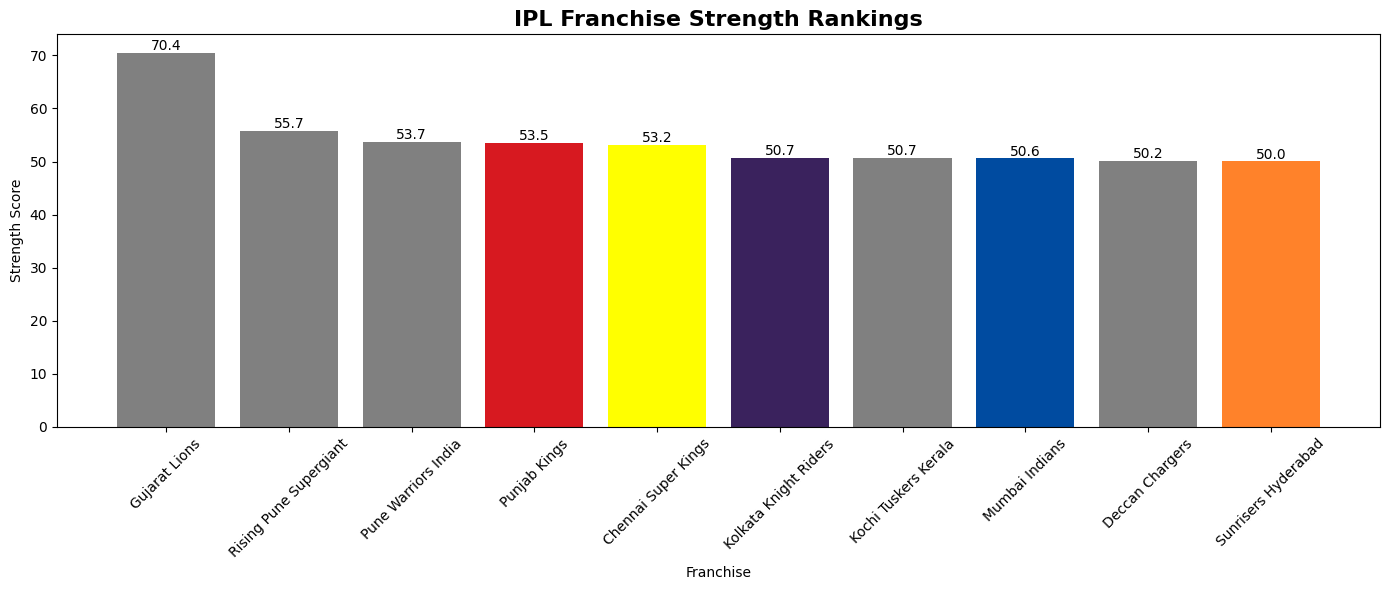

In [ ]:
import matplotlib.pyplot as plt

TEAM_COLORS = {
    "Chennai Super Kings": "#FFFF00",      # Yellow
    "Mumbai Indians": "#004BA0",           # Blue
    "Royal Challengers Bengaluru": "#EC1C24", # Red
    "Kolkata Knight Riders": "#3A225D",    # Purple
    "Sunrisers Hyderabad": "#FF822A",      # Orange
    "Delhi Capitals": "#17449B",           # Dark Blue
    "Rajasthan Royals": "#FF69B4",         # Pink
    "Punjab Kings": "#D71920",             # Red
    "Gujarat Titans": "#1B2133",           # Navy Blue
    "Lucknow Super Giants": "#00AEEF"      # Sky Blue
}

top10 = franchise_rankings.head(10)

colors = [
    TEAM_COLORS.get(team, "#808080")
    for team in top10["team"]
]

plt.figure(figsize=(14,6))

bars = plt.bar(
    top10["team"],
    top10["strength_score"],
    color=colors
)

plt.title(
    "IPL Franchise Strength Rankings",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Franchise")
plt.ylabel("Strength Score")

plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height:.1f}",
        ha="center"
    )

plt.tight_layout()
plt.show()


In [ ]:
franchise_rankings.to_csv(
    "franchise_rankings.csv",
    index=False
)